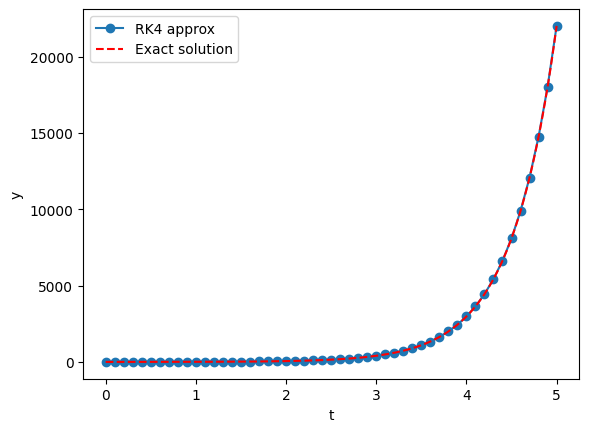

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math, torch, numpy as np

def f(t, y):
    return 2*y   # dy/dt = 2y

dt = 0.01
mult = math.exp(2*dt)            # exact one-step multiplier

def rk4_step(t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h*k1/2)
    k3 = f(t + h/2, y + h*k2/2)
    k4 = f(t + h, y + h*k3)
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# Parameters
t0, y0 = 0.0, 1.0   # initial condition y(0) = 1
h = 0.1             # step size
N = 50              # number of steps

# Integration
t_vals = [t0]
y_vals = [y0]

t, y = t0, y0
for _ in range(N):
    y = rk4_step(t, y, h)
    t += h
    t_vals.append(t)
    y_vals.append(y)

# Exact solution for comparison
t_exact = np.linspace(0, N*h, 200)
y_exact = y0 * np.exp(2*t_exact)

# Plot
plt.plot(t_vals, y_vals, 'o-', label="RK4 approx")
plt.plot(t_exact, y_exact, 'r--', label="Exact solution")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.show()


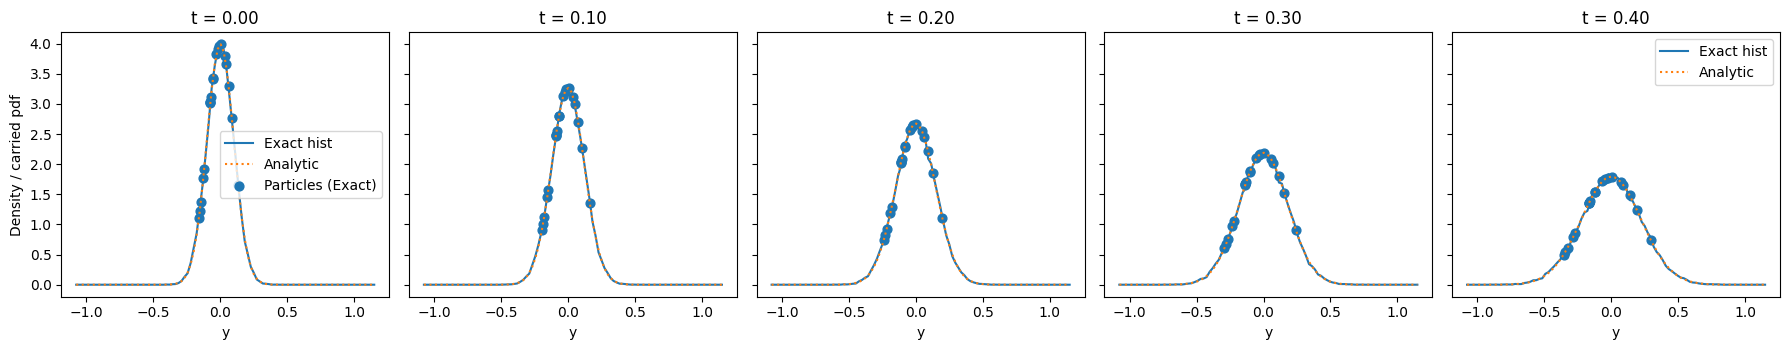

Exact multiplier e^(2*dt): 1.02020134
Snapshot times: 0.00, 0.10, 0.20, 0.30, 0.40


In [2]:
# Combined script: time-evolving PDFs with snapshot panels that mark 20 particles
# and update their positions over time. Each particle carries a "local pdf"
# value that is divided by m_exact at each integration step.

import numpy as np
import math
import matplotlib.pyplot as plt

# -----------------------------
# 1) Model multiplier (exact)
# -----------------------------
# Assumes you have mult and dt defined upstream (e.g., mult = math.exp(2*dt))
m_exact = mult  # exact discrete multiplier for dy/dt = 2y with step dt

# -----------------------------
# 2) Build ensemble and integrate over time
# -----------------------------
N_ens  = 50000
sigma0 = 0.1
steps  = 40
t      = np.arange(steps+1) * dt

y0 = np.random.normal(0.0, sigma0, size=N_ens)
Y_ex = np.zeros((steps+1, N_ens))
Y_ex[0] = y0.copy()

for k in range(steps):
    Y_ex[k+1] = m_exact * Y_ex[k]

# -----------------------------
# 3) Helper: Gaussian pdf
# -----------------------------
def gaussian_pdf(x, mu=0.0, sigma=1.0):
    return (1.0/(math.sqrt(2*math.pi)*sigma)) * np.exp(-0.5*((x-mu)/sigma)**2)

# -----------------------------
# 4) Choose 20 particles at t=0 and carry local pdf
#    Under linear map y -> m*y, Liouville mapping gives p_{k+1}(y) = p_k(y/m)/|m|.
#    Along a trajectory, the carried density scales by 1/|m| each step.
# -----------------------------
rng = np.random.default_rng()
Np  = 20
mu0 = 0.0
x0_particles = rng.normal(mu0, sigma0, size=Np)

# Initial local pdf carried by each particle (from initial Gaussian)
W0 = gaussian_pdf(x0_particles, mu0, sigma0)

# Allocate arrays for particle positions and carried pdfs over time
X_ex = np.zeros((steps+1, Np))
W_ex = np.zeros((steps+1, Np))
X_ex[0] = x0_particles.copy()
W_ex[0] = W0.copy()

for k in range(steps):
    # propagate positions
    X_ex[k+1] = m_exact * X_ex[k]
    # propagate carried pdfs (divide by mapping multiplier each step)
    W_ex[k+1] = W_ex[k] / abs(m_exact)

# -----------------------------
# 5) Snapshot PDFs at selected times with particle markers
#    - Histogram (Exact) and analytic Gaussian overlay at each time
#    - Particles plotted at (x_k, carried_pdf_k) for Exact (circles)
# -----------------------------
# Global bins for consistent histograms across panels
y_all_min = Y_ex.min()
y_all_max = Y_ex.max()
pad = 0.1 * (y_all_max - y_all_min + 1e-12)
bins = np.linspace(y_all_min - pad, y_all_max + pad, 100+1)

# Snapshot times (you can change as needed)
# snap_times = [0.0, 0.5, 1.0, 1.5, 2.0]
snap_times = [0.0, 0.1, 0.2, 0.3, 0.4]
snap_idx = [np.argmin(np.abs(t - ts)) for ts in snap_times]

cols = len(snap_idx)
fig, axes = plt.subplots(1, cols, figsize=(3.6*cols, 3.6), sharey=True)
if cols == 1:
    axes = [axes]

for j, (ax, k) in enumerate(zip(axes, snap_idx)):
    # Histogram density
    counts_ex, edges = np.histogram(Y_ex[k], bins=bins, density=True)
    centers = 0.5*(edges[:-1] + edges[1:])

    # Analytic Gaussian at time t[k] (mean 0, sigma(t) = sigma0 * e^{2t})
    sig_k = sigma0 * math.exp(2*t[k])
    pdf_k = gaussian_pdf(centers, mu0, sig_k)

    # Curves
    ax.plot(centers, counts_ex, label='Exact hist')
    ax.plot(centers, pdf_k, linestyle=':', label='Analytic')

    # Particle markers at their current positions with carried pdf as y-value
    ax.scatter(X_ex[k], W_ex[k], marker='o', s=40, label='Particles (Exact)' if j==0 else None)

    ax.set_title(f't = {t[k]:.2f}')
    ax.set_xlabel('y')
    if j == 0:
        ax.set_ylabel('Density / carried pdf')

# One legend for the first panel
axes[0].legend()
plt.legend(); plt.tight_layout()
plt.savefig("final_time_distribution.png", dpi=300)  # save
plt.show()

# -----------------------------
# 6) Report multiplier
# -----------------------------
print(f"Exact multiplier e^(2*dt): {m_exact:.8f}")
print(f"Snapshot times: {', '.join(f'{st:.2f}' for st in snap_times)}")


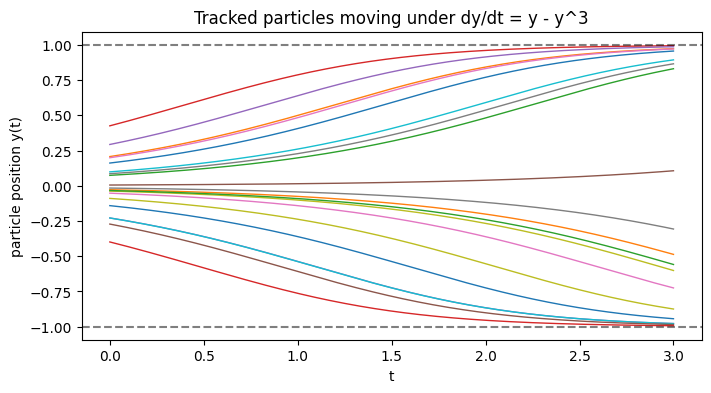

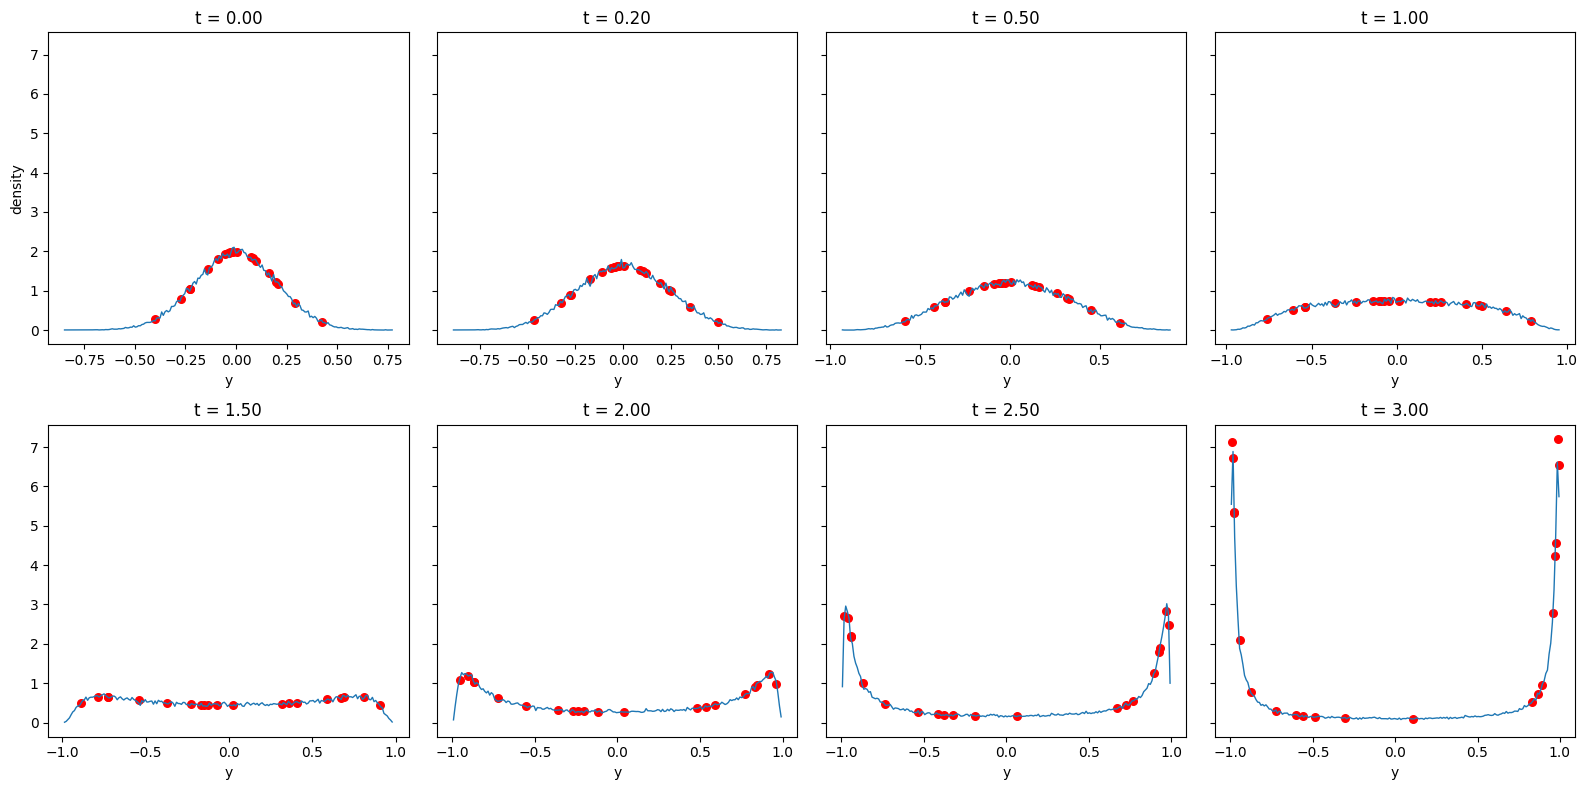

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ============================================================
# 1) Dynamics and Liouville ODEs
# ============================================================
def f_y(y):
    """dy/dt = y - y^3."""
    return y - y**3

def f_W(y, W):
    """Liouville: dW/dt = -W * div(f) = -W*(1 - 3y^2)."""
    return -W * (1.0 - 3.0*y**2)

def rk4_step_yW(y, W, dt):
    """Joint RK4 for the pair (y, W)."""
    # k1
    k1_y = f_y(y)
    k1_W = f_W(y, W)

    # k2
    y2 = y + 0.5 * dt * k1_y
    W2 = W + 0.5 * dt * k1_W
    k2_y = f_y(y2)
    k2_W = f_W(y2, W2)

    # k3
    y3 = y + 0.5 * dt * k2_y
    W3 = W + 0.5 * dt * k2_W
    k3_y = f_y(y3)
    k3_W = f_W(y3, W3)

    # k4
    y4 = y + dt * k3_y
    W4 = W + dt * k3_W
    k4_y = f_y(y4)
    k4_W = f_W(y4, W4)

    y_next = y + (dt/6)*(k1_y + 2*k2_y + 2*k3_y + k4_y)
    W_next = W + (dt/6)*(k1_W + 2*k2_W + 2*k3_W + k4_W)

    return y_next, W_next

# ============================================================
# 2) Ensemble for histogram
# ============================================================
dt = 0.01
steps = 300   # extend time to see convergence toward ±1

N_ens = 50000
sigma0 = 0.2
mu0 = 0.0

rng = np.random.default_rng()
Y = np.zeros((steps+1, N_ens))
Y[0] = rng.normal(mu0, sigma0, size=N_ens)

# Integrate ensemble
for k in range(steps):
    Y[k+1] = Y[k] + dt*(Y[k] - Y[k]**3)

# ============================================================
# 3) Tracked particles + Liouville density
# ============================================================
Np = 20
x0 = rng.normal(mu0, sigma0, size=Np)

def gaussian_pdf(x, mu, sigma):
    return 1.0/(sigma*np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2/(2*sigma**2))

W0 = gaussian_pdf(x0, mu0, sigma0)

X = np.zeros((steps+1, Np))
W = np.zeros((steps+1, Np))
X[0] = x0.copy()
W[0] = W0.copy()

for k in range(steps):
    for j in range(Np):
        X[k+1,j], W[k+1,j] = rk4_step_yW(X[k,j], W[k,j], dt)

# ============================================================
# 4) Plot: particles advect toward ±1
# ============================================================
plt.figure(figsize=(8,4))
for j in range(Np):
    plt.plot(np.arange(steps+1)*dt, X[:,j], lw=1)

plt.axhline(1, color='k', linestyle='--', alpha=0.5)
plt.axhline(-1, color='k', linestyle='--', alpha=0.5)
plt.xlabel("t")
plt.ylabel("particle position y(t)")
plt.title("Tracked particles moving under dy/dt = y - y^3")
plt.show()

# ============================================================
# 5) Snapshot PDFs + Liouville weights
# ============================================================
snap_idx = [0, 20, 50, 100, 150, 200, 250, 300]

fig, axes = plt.subplots(2, 4, figsize=(16,8), sharey=True)
axes = axes.ravel()

for ax, k in zip(axes, snap_idx):
    counts, edges = np.histogram(Y[k], bins=200, density=True)
    centers = 0.5*(edges[:-1] + edges[1:])

    ax.plot(centers, counts, lw=1)
    ax.scatter(X[k], W[k], s=30, color='red')

    ax.set_title(f"t = {k*dt:.2f}")
    ax.set_xlabel("y")

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()
